In [1]:
import sys
sys.path.append("..")

# Riemannian Deformation Grid on Stereo-seq Mouse Embryo

This notebook visualizes the Riemannian deformation grid learned by MGW on a consecutive Stereo-seq mouse embryo pair (E9.5 → E10.5).

Each spatial coordinate carries a 2×2 pullback metric tensor $g_{\mu\nu}(x) = J_\varphi(x)^\top J_\varphi(x)$ encoding how the learned embedding $\varphi$ locally stretches the tissue. The deformation grid plots level sets of two harmonic coordinate fields solved on the Riemannian kNN graph, with a grayscale heatmap of log-anisotropy $\log(\lambda_{\max}/\lambda_{\min})$ as background.

For geodesic visualization on the same data, see `riemannian_mouse_geodesics.ipynb`.

In [2]:

import scanpy as sc
import anndata as ad
import numpy as np, torch, scipy.sparse as sp
from mgw import util, models, plotting, geometry
from mgw import pullback_metric_field, knn_graph
from mgw.gw import solve_gw_ott
import importlib
import matplotlib.pyplot as plt
import os

# ----------------------------
# Runtime & device setup
# ----------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_dtype(torch.float64)
print("Device:", device)

# ----------------------------
# Input files & parameters
# ----------------------------
filehandles_embryo_adata = [
    '/scratch/gpfs/BRAPHAEL/ph3641/mouse_embryo/E9.5_E1S1.MOSTA.h5ad',
    '/scratch/gpfs/BRAPHAEL/ph3641/mouse_embryo/E10.5_E1S1.MOSTA.h5ad',
    '/scratch/gpfs/BRAPHAEL/ph3641/mouse_embryo/E11.5_E1S1.MOSTA.h5ad',
    '/scratch/gpfs/BRAPHAEL/ph3641/mouse_embryo/E12.5_E1S1.MOSTA.h5ad',
    '/scratch/gpfs/BRAPHAEL/ph3641/mouse_embryo/E13.5_E1S1.MOSTA.h5ad'
]
timepoints = ['E9.5', 'E10.5', 'E11.5', 'E12.5', 'E13.5']

# Embedding / network parameters
PCA_comp   = 30
knn_k      = 12
geodesic_eps = 0.01

gw_params = dict(verbose=True, inner_maxit=3000, outer_maxit=3000,
                 inner_tol=1e-7, outer_tol=1e-7, epsilon=1e-4)

save_dir = "/scratch/gpfs/BRAPHAEL/ph3641/mgw/ME_Alignments"
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# 1. Load datasets and prepare
# ============================================================
print('Loading AnnData slices...')
adatas = []
for i, fh in enumerate(filehandles_embryo_adata):
    adata = sc.read_h5ad(fh)
    adata.X = adata.layers['count']
    adata.obs['timepoint'] = [timepoints[i]] * adata.shape[0]
    adatas.append(adata)

# Intersect genes across all slices
common_genes = list(set.intersection(*[set(a.var_names) for a in adatas]))
adatas = [a[:, common_genes] for a in adatas]
print(f"Common genes: {len(common_genes)}")


Device: cuda
Loading AnnData slices...
Common genes: 23787


In [3]:
from mgw import metrics
from mgw import mgw as mgw
from scipy.spatial.distance import cdist

# ============================================================
# 2. Loop over consecutive pairs (E11.5→E12.5, E12.5→E13.5)
# ============================================================
importlib.reload(geometry)

N_downsample = 10_000

ad1, ad2 = adatas[0], adatas[1]
tp1, tp2 = timepoints[0], timepoints[1]

print(f"\n--- Aligning {tp1} → {tp2} ---")

# Normalization, log1p, PCA
joint = ad.concat([ad1, ad2], join='inner')

sc.pp.normalize_total(joint)
sc.pp.log1p(joint)
sc.pp.pca(joint, n_comps=PCA_comp)

# Split back into slices
A = joint[joint.obs['timepoint'] == tp1].copy()
B = joint[joint.obs['timepoint'] == tp2].copy()

# ========================================================
# (a) Feature preprocessing (PCA + CCA "feeler")
# ========================================================
pre = mgw.mgw_preprocess(
        A, B,
        PCA_comp=10,
        CCA_comp=10,
        use_cca_feeler=False,
        use_pca_X=True,
        use_pca_Z=True,
        log1p_X=False,
        log1p_Z=False,
        verbose=True,
        feature_only=True,
        spatial_only=False
    )



--- Aligning E9.5 → E10.5 ---


/home/ph3641/.conda/envs/peterenv2/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[mgw.pre] PCA/raw shapes: X=(5913, 10)  Z=(18408, 10)


In [4]:
out = mgw.mgw_align_core(
    pre,
    widths=(128, 256, 256, 128),
    lr=1e-3,
    niter=20_000,
    knn_k=knn_k,
    geodesic_eps=1e-5,
    gw_params=gw_params,
    device=device,
    save_dir=save_dir,
    tag=f'{tp1}_{tp2}',
    verbose=True,
)

xs, xs2 = out['xs'], out['xs2']

[mgw.core] device=cuda dtype=torch.float64
[mgw.core] dims: E=2, F_M=10, F_N=10
[mgw.core] training φ, ψ
[train_phi] step=1000 loss=0.024337
[train_phi] step=2000 loss=0.015373
[train_phi] step=3000 loss=0.011589
[train_phi] step=4000 loss=0.009993
[train_phi] step=5000 loss=0.009109
[train_phi] step=6000 loss=0.008708
[train_phi] step=7000 loss=0.007586
[train_phi] step=8000 loss=0.007110
[train_phi] step=9000 loss=0.006938
[train_phi] step=10000 loss=0.006470
[train_phi] step=11000 loss=0.006324
[train_phi] step=12000 loss=0.005907
[train_phi] step=13000 loss=0.005702
[train_phi] step=14000 loss=0.005535
[train_phi] step=15000 loss=0.005446
[train_phi] step=16000 loss=0.005741
[train_phi] step=17000 loss=0.005087
[train_phi] step=18000 loss=0.005211
[train_phi] step=19000 loss=0.005134
[train_phi] step=20000 loss=0.004984
[train_phi] step=1000 loss=0.049913
[train_phi] step=2000 loss=0.029789
[train_phi] step=3000 loss=0.025234
[train_phi] step=4000 loss=0.030815
[train_phi] step=500

## Deformation Grid

Grid lines are level sets of two harmonic coordinate fields $u$ (left→right) and $v$ (bottom→top), solved on the Riemannian kNN graph via the discrete Laplace-Beltrami operator with Dirichlet boundary conditions. The background heatmap shows local metric anisotropy $\log(\lambda_{\max}/\lambda_{\min})$, where $\lambda_{\max}/\lambda_{\min}$ are the eigenvalues of $g_{\mu\nu}(x)$.

In [5]:
from mgw.tensor_vis import plot_deformation_grids

  Solving harmonic coords for E9.5   $\varphi: \mathcal{E} \to \mathcal{M}$...
  Solving harmonic coords for E10.5   $\psi: \mathcal{E} \to \mathcal{N}$...
Saved → /scratch/gpfs/BRAPHAEL/ph3641/mgw/ME_Alignments/deformation_grid_E9.5_E10.5.*


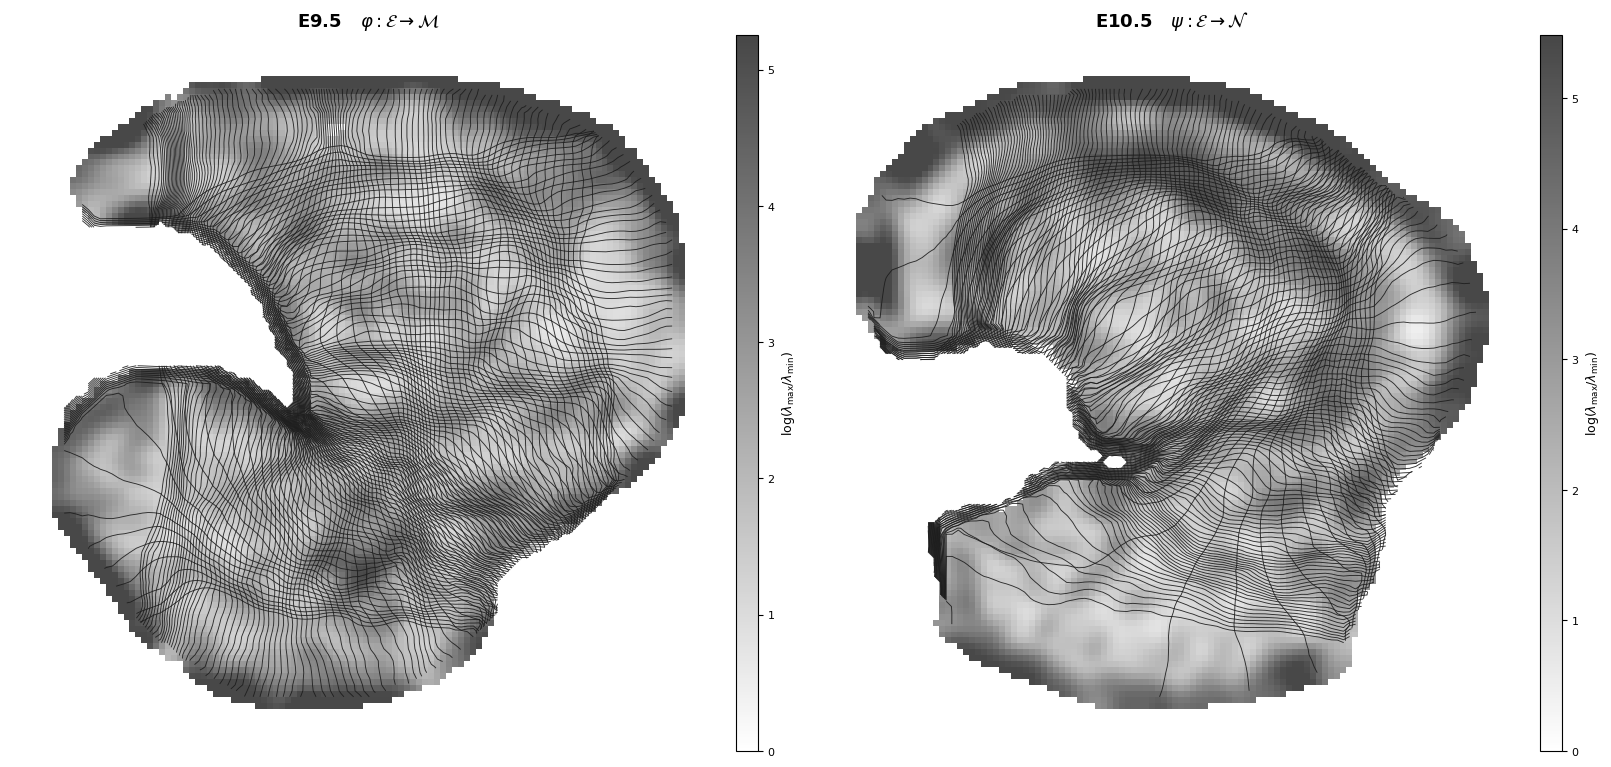

In [6]:
fig = plot_deformation_grids(
    out,
    labels=[
        f'{tp1}   $\\varphi: \\mathcal{{E}} \\to \\mathcal{{M}}$',
        f'{tp2}   $\\psi: \\mathcal{{E}} \\to \\mathcal{{N}}$',
    ],
    n_lines=100, smooth_contour=0.1,
    sigma_smooth=0.5, pad=0.08,
    save=os.path.join(save_dir, 'deformation_grid_E9.5_E10.5'),
)
plt.show()